# Dual-phase MC-PILCO — evaluation & comparison

Notebook counterpart to `evaluations_multi_phase.py` (the CLI script) — both import every
plot/table from `eval_multi_phase_lib.py`, so there is exactly one implementation and running
either produces the same saved PNGs/CSVs in the run's own folder
(`results/dual_phase/<run_id>/`).

Set `RUN_ID` in the **Config** cell (e.g. `"seed3_1"`) and run top-to-bottom — everything else
(seed, num_trials, pivot_hours, the trained policy, the trained GPs) is read back from that
run's own `note.txt`/`log.pkl`/`monitor.pkl`.

- **A** — RL policy vs same-seed PID/recipe baseline (paired yield statistics + seed-averaged
  trajectories + validation learning curve).
- **B** — training progression (per-episode trajectories, all observations, Fs residual).
- **C** — GP model diagnostics, scored **per phase**: one-step fit/MSE (phase1 vs phase2,
  since `DualPhaseModelLearning` evaluates each phase's GPs on its own data segment), plus
  multi-step rollout/particle-band/calibration/local-error/k-step-growth diagnostics over the
  full trajectory with a marker at the pivot so you can see where (and whether) fit quality
  changes at the phase switch.

(Short-horizon/recipe-anchor diagnostics from the single-phase notebook are not included here
-- anchors/optim-horizon are an unsupported combination with dual-phase.)


## 0. Setup & Config

In [1]:
%matplotlib inline
import os as _os, sys as _sys
_ROOT = _os.path.dirname(_os.path.abspath(""))
if _ROOT not in _sys.path:
    _sys.path.insert(0, _ROOT)

import evaluations.eval_multi_phase_lib as lib

RUN_ID = "seed3_1"          # resolved under results/dual_phase/, or a full/relative path
GP_TRIAL = None             # which trial's GP model to diagnose in section C (None = last saved)
N_EVAL_SEEDS = 5            # held-out seeds for section A
EVAL_BASE = 700000
COMPARE_SEED = EVAL_BASE

run = lib.load_run(RUN_ID)
OUT_DIR = run.dir
run.params


log/code state check OK: state_dim=5, channels=['Wt', 'X', 'P', 'Viscosity', 'time']
run: /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/results/dual_phase/seed3_1  |  episodes: 10  |  trials in log: 5  |  pivot: 100 h


{'seed': 3,
 'num_trials': 5,
 'fast': False,
 'out_dir': None,
 'pivot_hours': 100.0,
 'risk_weight': 0.0,
 'visc_penalty': 0.5,
 'harvest_reward': True}

# A. RL policy vs same-seed PID baseline

The recipe/PID baseline runs on the **same seed** as the RL policy, so each pair shares an
identical stochastic batch realisation and only the Fs (sugar-feed) action differs. Evaluated
on a block of held-out seeds disjoint from training.

In [2]:
policy_agent, eval_wrapper, np_policy, ref, ref_lbl = lib.build_policy_agent(run)




Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


[recipe-mean] Viscosity: 45 decisions from 4 recipe batches, normalised delta range [-0.1081, 0.0977]
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


loaded trial 5 policy | recipe baseline on seed 3000: final_P=25.61 g/L, yield=3246.7 kg


## A.1-A.2 Held-out evaluation & paired statistics

In [3]:
df, mons_rl, mons_recipe = lib.eval_held_out(
    run, np_policy, eval_wrapper, OUT_DIR, n_eval_seeds=N_EVAL_SEEDS, eval_base=EVAL_BASE)
df


seed 700000: yield_rl= 3736.73  yield_recipe= 3467.33  delta= +269.40


seed 700001: yield_rl= 4130.88  yield_recipe= 3573.90  delta= +556.98


seed 700002: yield_rl= 3827.03  yield_recipe= 3696.62  delta= +130.41


seed 700003: yield_rl= 3997.44  yield_recipe= 3526.59  delta= +470.85


seed 700004: yield_rl= 3505.05  yield_recipe= 3214.51  delta= +290.54


,seed,yield_rl,yield_recipe,delta,rl_final_P,rl_max_Wt,rl_wt_overflow,rl_paa_frac_out_of_band,rl_max_viscosity,rl_visc_exceed,recipe_final_P,recipe_max_Wt,recipe_wt_overflow,recipe_paa_frac_out_of_band,recipe_max_viscosity,recipe_visc_exceed
0,700000,3736.729412,3467.328902,269.400510,28.671317,105569.201463,False,0.011304,83.402873,False,27.424360,101050.051771,False,0.011304,81.007048,False
1,700001,4130.880464,3573.899211,556.981254,30.608182,112242.756795,False,0.019130,76.869365,False,27.762091,106086.753636,False,0.019130,71.801539,False
2,700002,3827.025470,3696.618223,130.407247,30.170970,100833.775484,False,0.000000,91.608689,False,30.024651,98603.657446,False,0.000000,89.916614,False
3,700003,3997.438893,3526.588600,470.850293,29.314133,112204.404027,False,0.020000,80.368853,False,27.108314,105621.700489,False,0.020870,75.306299,False
4,700004,3505.050132,3214.506607,290.543525,26.129383,108085.420690,False,0.023478,81.820920,False,24.884472,101732.672304,False,0.024348,79.894066,False


In [4]:
summary = lib.paired_stats(df, OUT_DIR)
summary


=== SUMMARY (RL vs recipe, held-out) ===
n_seeds                  5.000000
mean_yield_rl         3839.424874
mean_yield_recipe     3495.788309
mean_delta             343.636566
delta_ci95_lo          194.692109
delta_ci95_hi          492.581023
ttest_p                  0.010642
wilcoxon_p               0.062500
winrate_rl_gt_recipe     1.000000


,n_seeds,mean_yield_rl,mean_yield_recipe,mean_delta,delta_ci95_lo,delta_ci95_hi,ttest_p,wilcoxon_p,winrate_rl_gt_recipe
0,5,3839.424874,3495.788309,343.636566,194.692109,492.581023,0.010642,0.0625,1.0


## A.3-A.5 Paired yield / total yield / seed-averaged variables

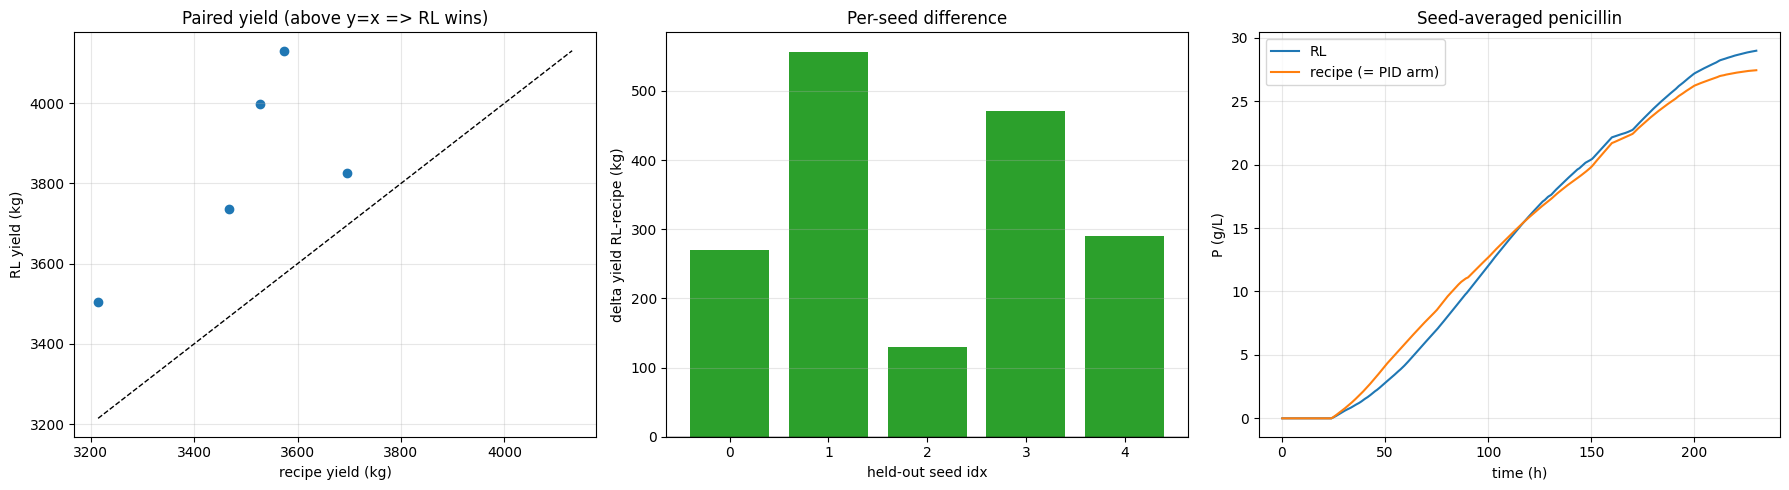

In [5]:
lib.plot_paired_yield(df, mons_rl, mons_recipe, OUT_DIR, show=True);


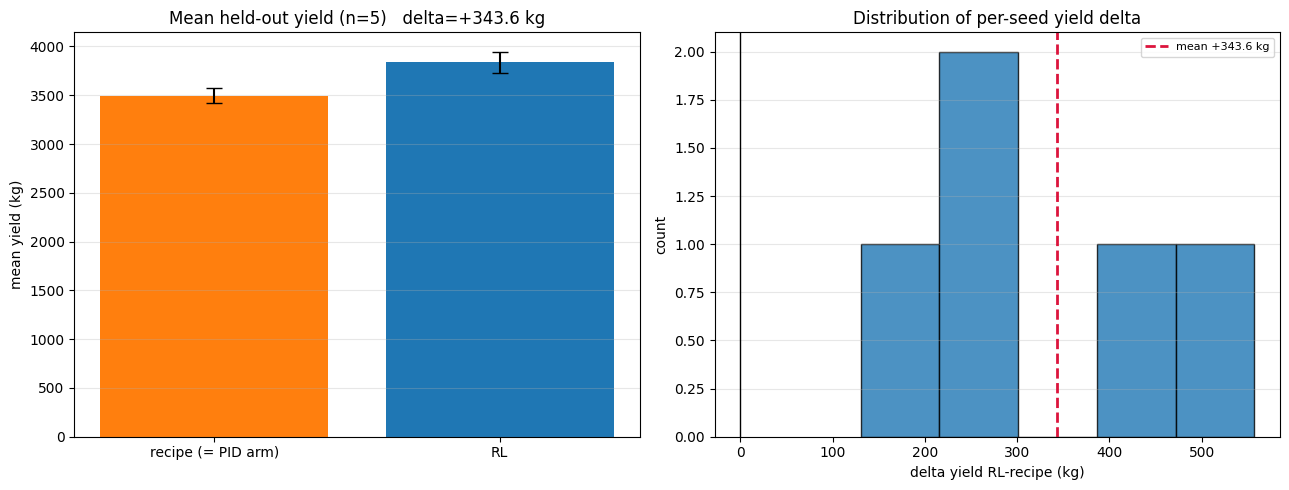

In [6]:
lib.plot_total_yield(df, OUT_DIR, show=True);


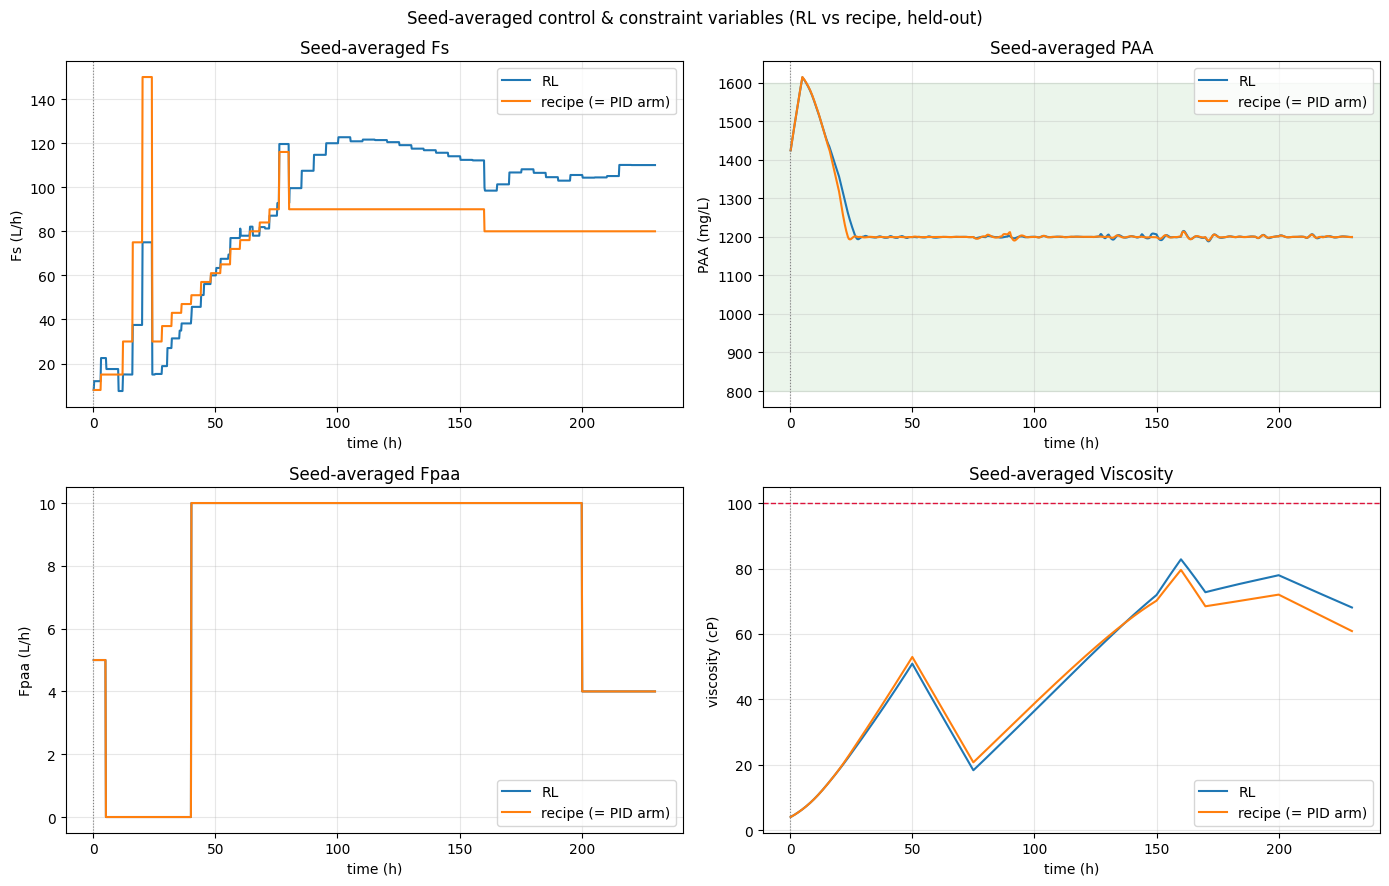

In [7]:
lib.plot_seed_avg_vars(mons_rl, mons_recipe, OUT_DIR, show=True);


## A.6-A.7 Model vs recipe on a single shared seed, Fs residual

seed 700000: yield model= 3736.73 kg  recipe= 3467.33 kg  delta= +269.40 kg


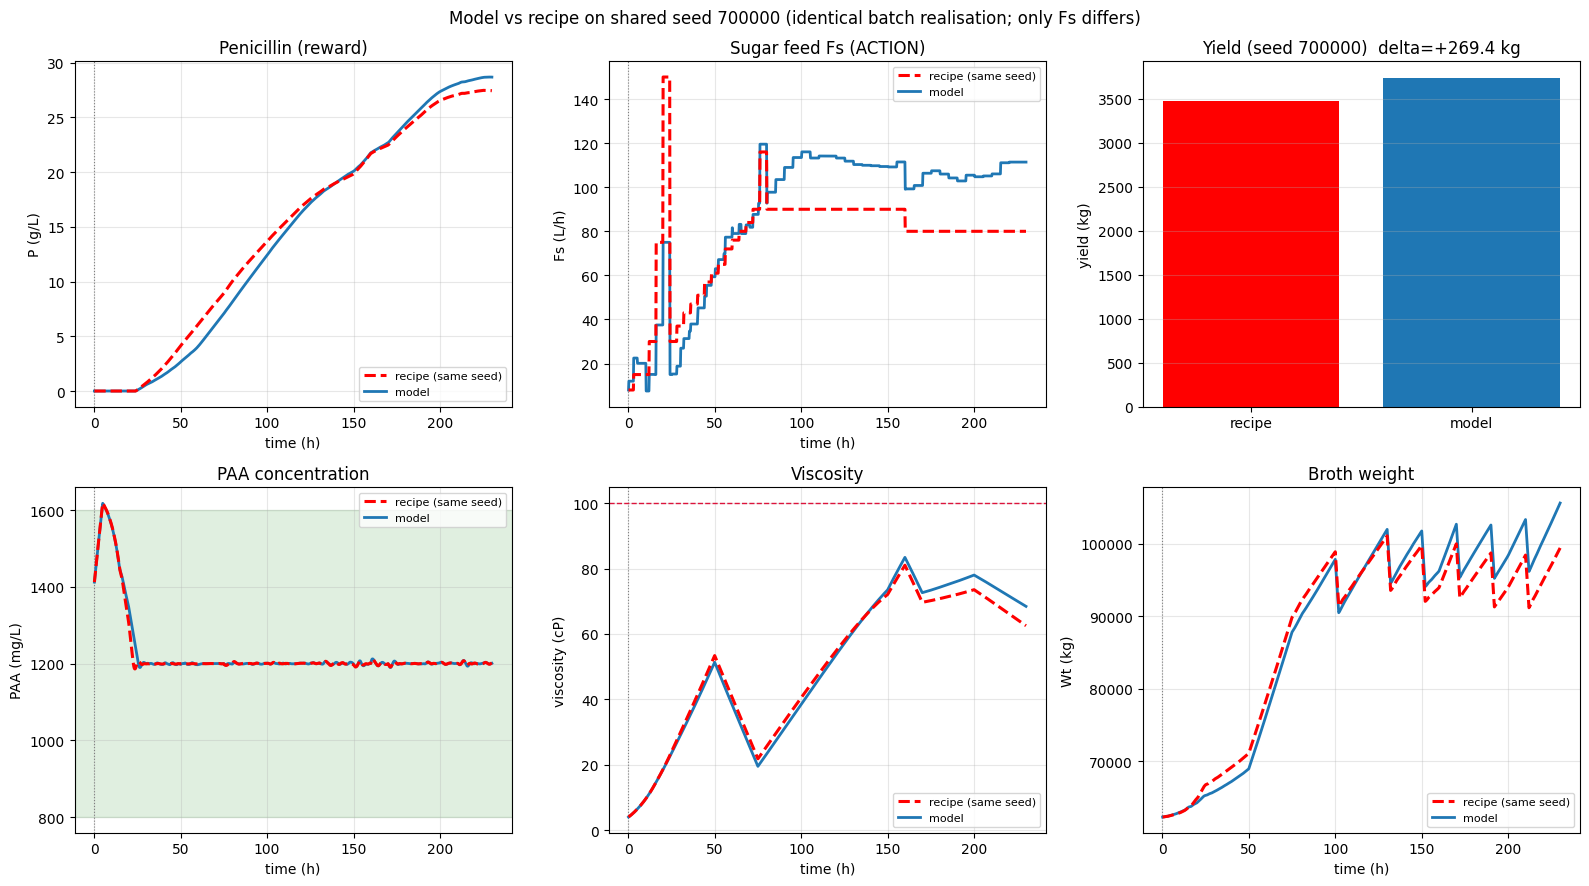

In [8]:
_, m_rl_s, m_recipe_s = lib.plot_model_vs_recipe_single_seed(
    eval_wrapper, np_policy, COMPARE_SEED, OUT_DIR, show=True)


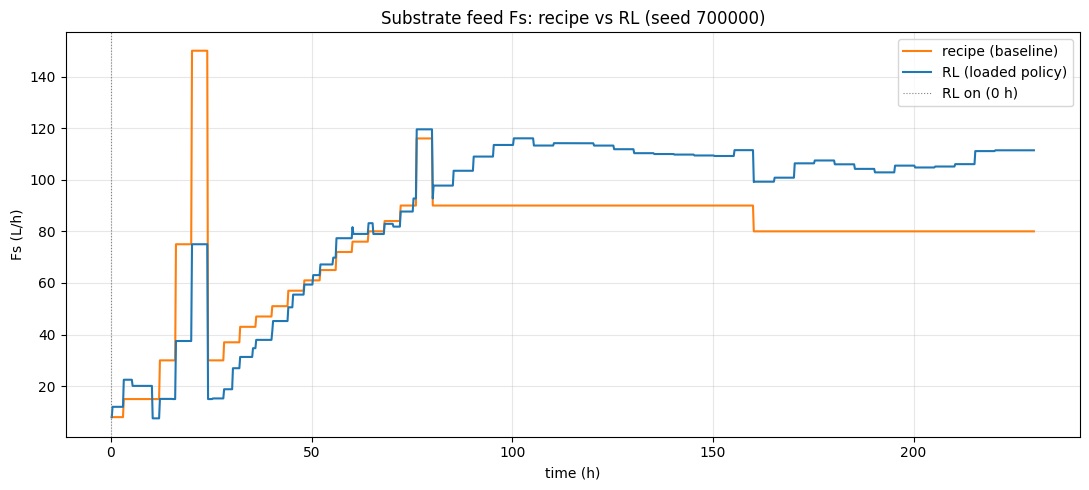

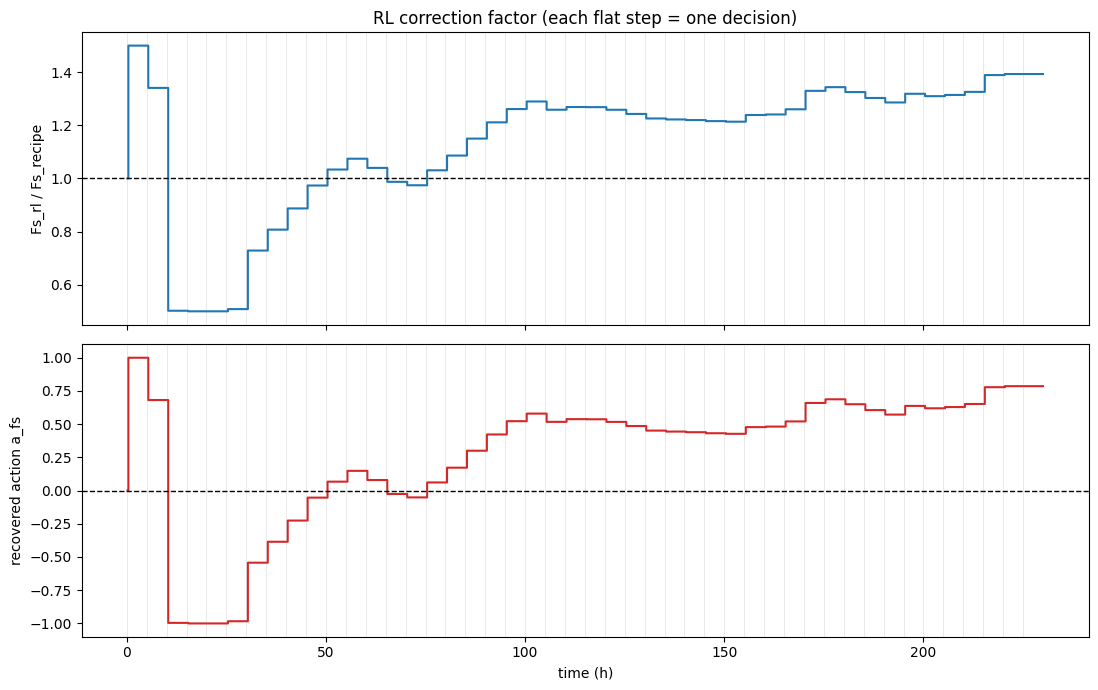

distinct action levels held over the batch: 45 (expected ~45 at T_SAMPLING=5 h)


In [9]:
lib.plot_fs_residual(m_rl_s, m_recipe_s, COMPARE_SEED, OUT_DIR, show=True);


## A.8 Validation learning curve (fixed seeds) — does the policy actually improve?

Seeds are held fixed and only the policy stage varies (loaded from `log["parameters_trial_list"]`),
each stage paired against the recipe on the same seed -- so seed variance cancels and any trend
is genuinely the policy.

recipe baseline on [700000, 700001, 700002]: 3579.3 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  1: yield=  2699.5 +/- 1485.6 kg | paired delta vs recipe =   -879.8 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  2: yield=  3602.9 +/- 502.8 kg | paired delta vs recipe =    +23.6 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  3: yield=  3664.5 +/- 431.3 kg | paired delta vs recipe =    +85.3 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  4: yield=  3788.4 +/- 366.4 kg | paired delta vs recipe =   +209.2 kg


Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...


  trial  5: yield=  3898.2 +/- 168.6 kg | paired delta vs recipe =   +318.9 kg


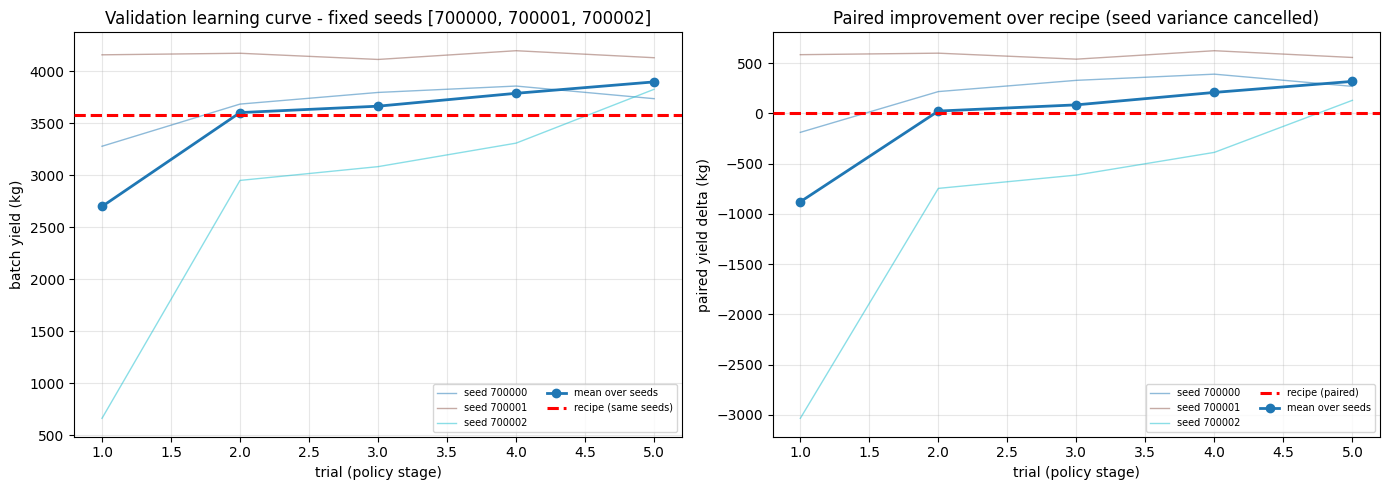

final policy: 3898.2 kg vs recipe 3579.3 kg (paired delta +318.9 kg) -> ABOVE recipe


,trial,mean_yield,std_yield,paired_delta
0,1,2699.507080,1485.623987,-879.775032
1,2,3602.910282,502.814364,23.628170
2,3,3664.538203,431.327148,85.256091
3,4,3788.443167,366.414737,209.161054
4,5,3898.211782,168.600872,318.929670


In [10]:
eval_seeds = [EVAL_BASE + i for i in range(N_EVAL_SEEDS)]
VAL_SEEDS = eval_seeds[:-2] if len(eval_seeds) > 2 else eval_seeds
_, learning_curve_df = lib.validation_learning_curve(run, eval_wrapper, OUT_DIR, VAL_SEEDS, show=True)
learning_curve_df


# B. Training progression (single run, all episodes)

How the run evolved across episodes (grey = exploration, viridis early->late = trials),
overlaid with the fixed recipe reference batch. The purple dotted line marks the dual-phase
pivot (`run.pivot_hours`).

## B.1 Reward, PAA, viscosity, Fpaa, penicillin trajectories, yield per episode

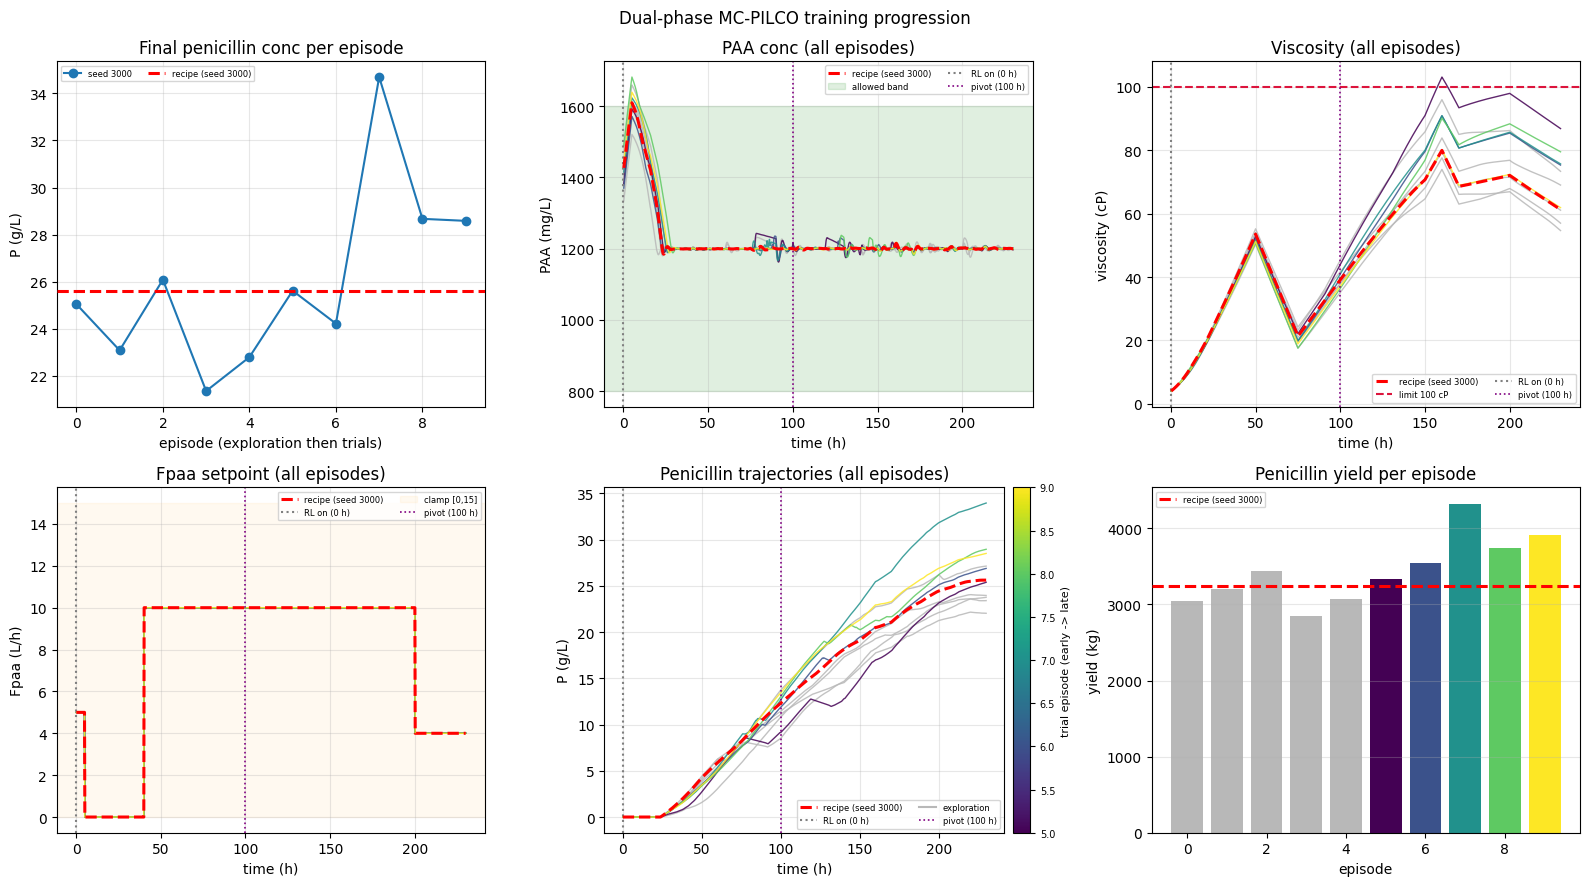

In [11]:
lib.plot_training_progression(run, ref, ref_lbl, OUT_DIR, show=True);


## B.2 All observations per episode

/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/pensim_mcpilco/evaluations/eval_multi_phase_lib.py:704: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


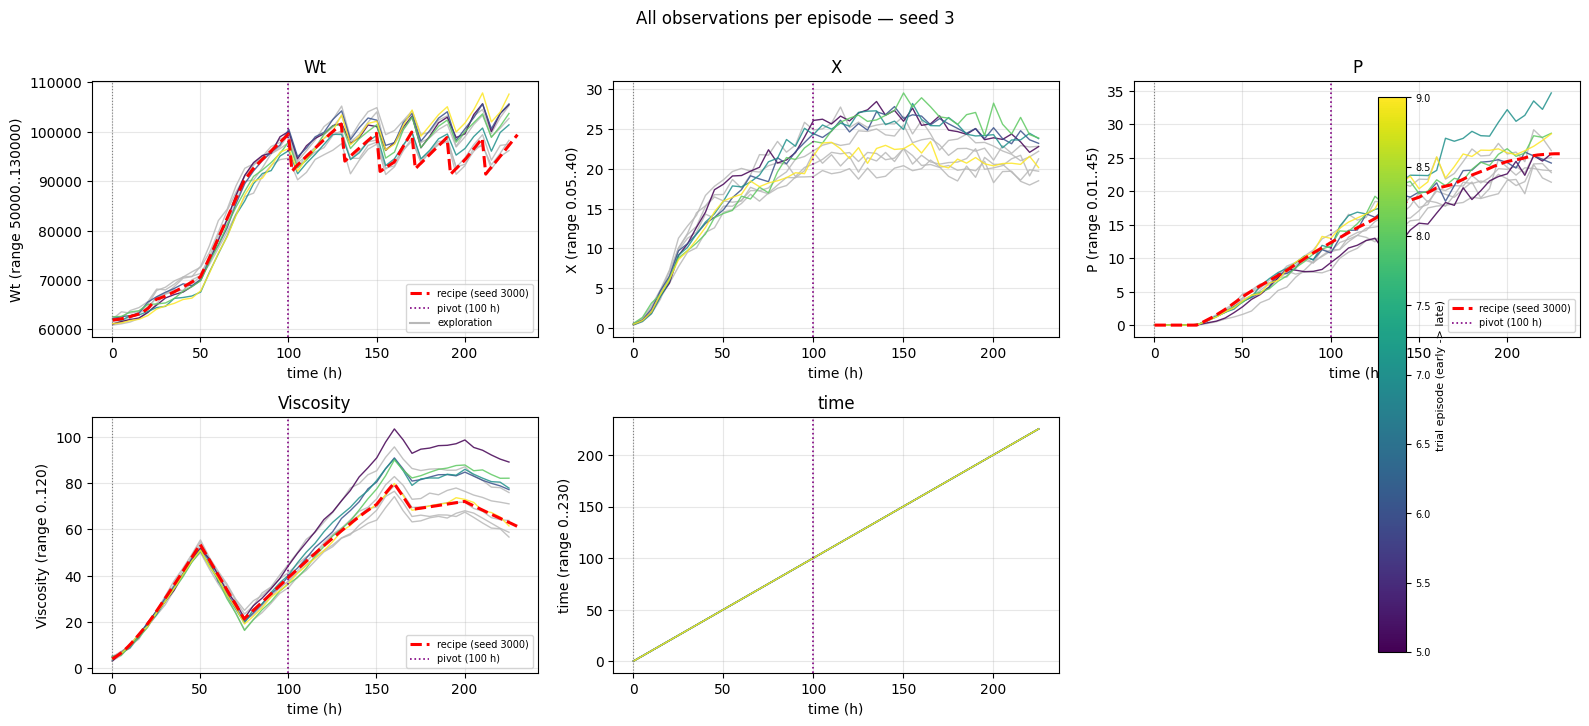

In [12]:
lib.plot_all_observations(run, ref, ref_lbl, OUT_DIR, show=True);


## B.3 Fs (sugar feed): recipe vs RL residual, all episodes

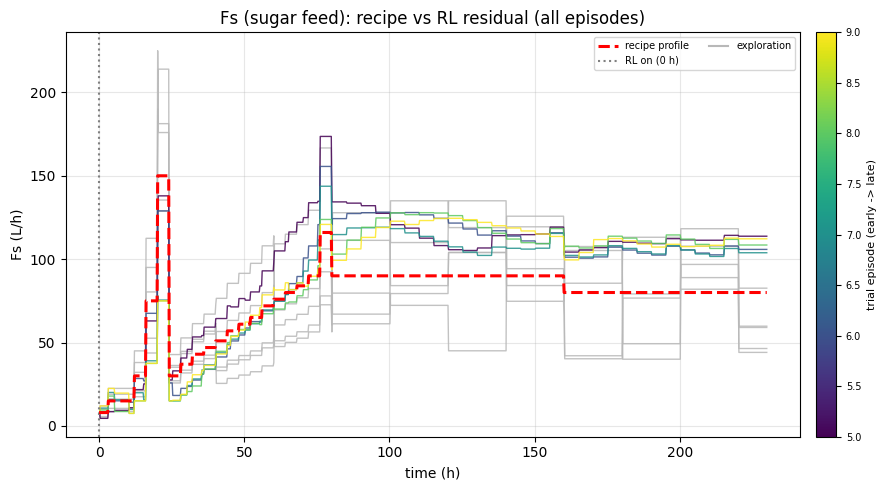

In [13]:
lib.plot_fs_all_episodes(run, OUT_DIR, show=True);


# C. GP model diagnostics

Is the learned GP dynamics model trustworthy over the horizon MC-PILCO optimises the policy
on -- and does that trustworthiness change at the phase switch? In-sample = the batch the GP
trained on; held-out = the next batch (collected under the trial-idx policy).

## C.1 Reconstruct the GP model

In [14]:
gp_agent, GP_IDX = lib.reconstruct_gp_agent(run, idx=GP_TRIAL)
ho_idx = GP_IDX + 1
has_ho = ho_idx < len(gp_agent.state_samples_history)
print(f"reconstructed GP model @ trial {GP_IDX} | has held-out batch: {has_ho}")




Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([112, 6])
MSE gp 0:  tensor(0.0003, dtype=torch.float64)

Selection of the inducing inputs...


/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/MC-PILCO/gpr_lib/GP_prior/GP_prior.py:106: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:1776.)
  U = torch.cholesky(K_X, upper=True)


Shape inducing inputs selected: torch.Size([159, 6])
MSE gp 1:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([178, 6])
MSE gp 2:  tensor(0.0005, dtype=torch.float64)

Selection of the inducing inputs...


Shape inducing inputs selected: torch.Size([115, 6])
MSE gp 3:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([152, 6])
MSE gp 4:  tensor(6.4004e-11, dtype=torch.float64)

Selection of the inducing inputs...


Shape inducing inputs selected: torch.Size([128, 6])
MSE gp 0:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([170, 6])
MSE gp 1:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...


Shape inducing inputs selected: torch.Size([140, 6])
MSE gp 2:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([127, 6])
MSE gp 3:  tensor(0.0002, dtype=torch.float64)

Selection of the inducing inputs...


Shape inducing inputs selected: torch.Size([168, 6])
MSE gp 4:  tensor(4.4110e-11, dtype=torch.float64)
reconstructed GP model @ trial 8 | has held-out batch: True


## C.1/C.3/C.4 One-step fit, per-dim MSE — scored per phase

`DualPhaseModelLearning.get_gp_estimate_from_data` evaluates each phase's GPs on its own data
segment, so these are naturally **2xSTATE_DIM** (phase1's channels, then phase2's) rather than
one shared fit.

MSE gp0:  0.0001901293223991031
MSE gp1:  0.00026897175349075624
MSE gp2:  0.0002178254653768781
MSE gp3:  0.00021511104094998937
MSE gp4:  4.434525645678511e-11
MSE gp5:  0.0001341437306538349
MSE gp6:  0.0003848462888555416
MSE gp7:  0.0001658726614300824
MSE gp8:  0.00023475914698292027
MSE gp9:  3.642154589765449e-11


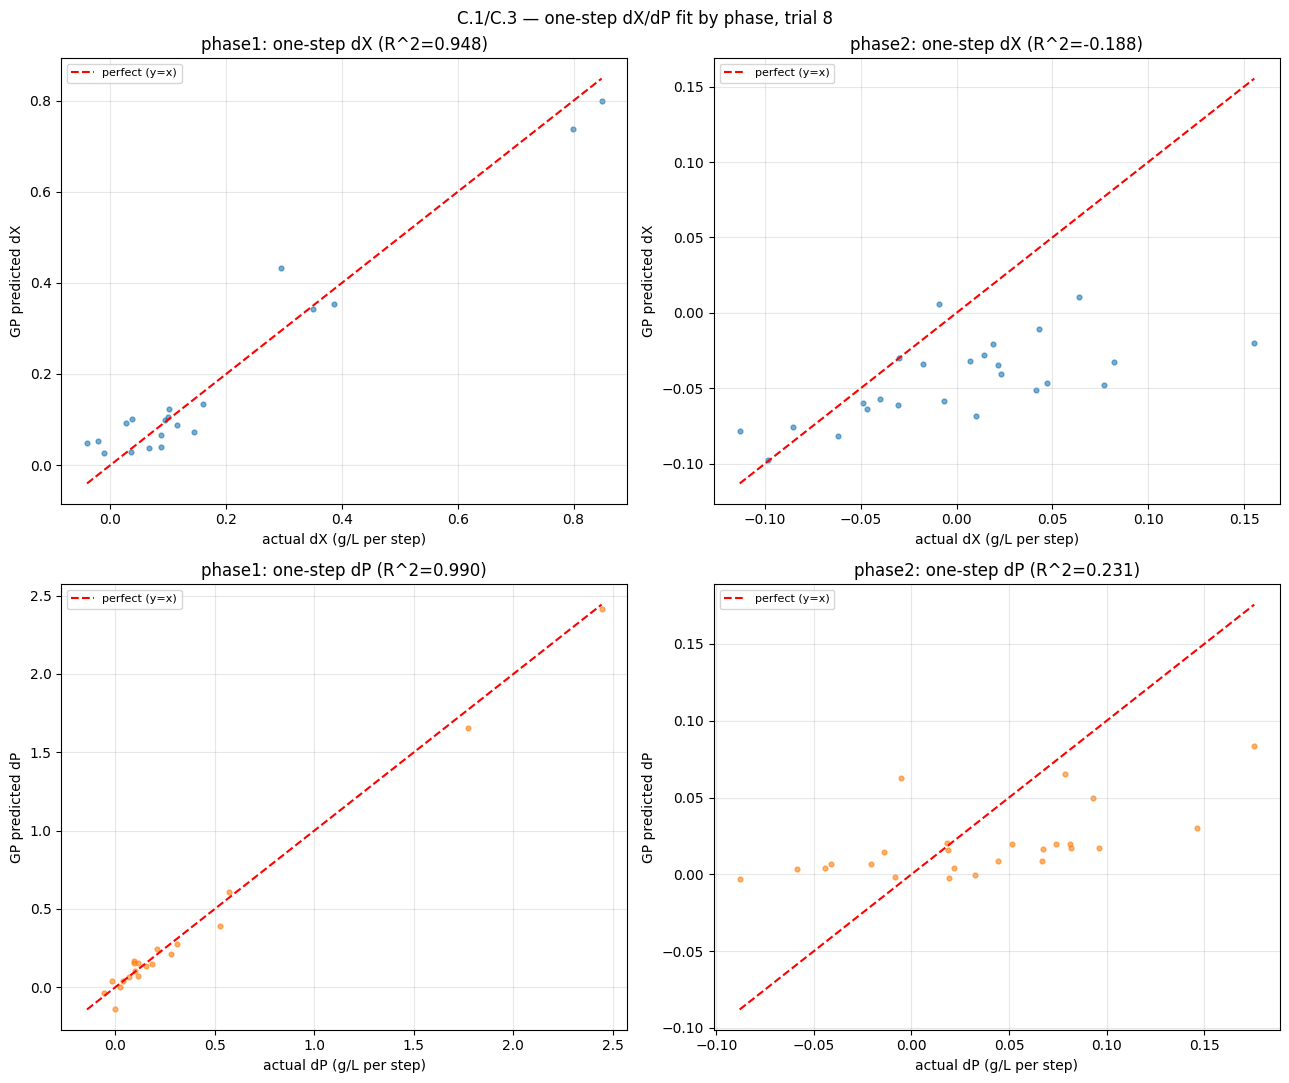

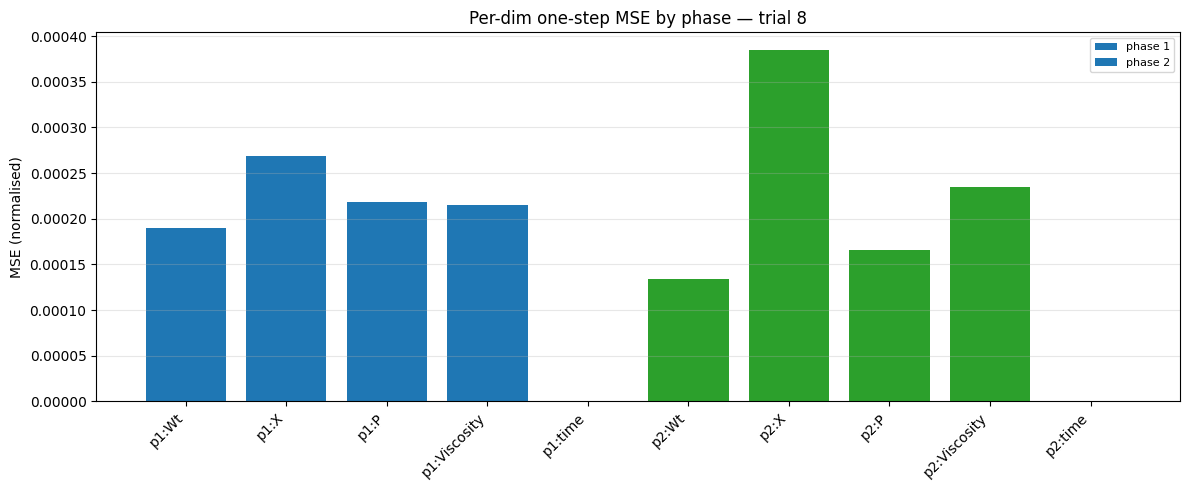

one-step R^2 -- phase1: X=0.948 P=0.990 | phase2: X=-0.188 P=0.231


In [15]:
per_dim_mse, one_step_results = lib.one_step_fit(gp_agent, GP_IDX, OUT_DIR, show=True)


## C.2 Multi-step X & P rollouts (in-sample vs held-out)

MSE Rollout dim0:  0.0007857023407383666
MSE Rollout dim1:  0.0009053505400486457
MSE Rollout dim2:  0.0008496513077479077
MSE Rollout dim3:  0.004075097229036933
MSE Rollout dim4:  4.5301221735369334e-31
MSE Rollout dim0:  0.0008146851925299269
MSE Rollout dim1:  0.0004945484472028713
MSE Rollout dim2:  0.0028627611307021693
MSE Rollout dim3:  0.007940548078249872
MSE Rollout dim4:  4.5301221735369334e-31


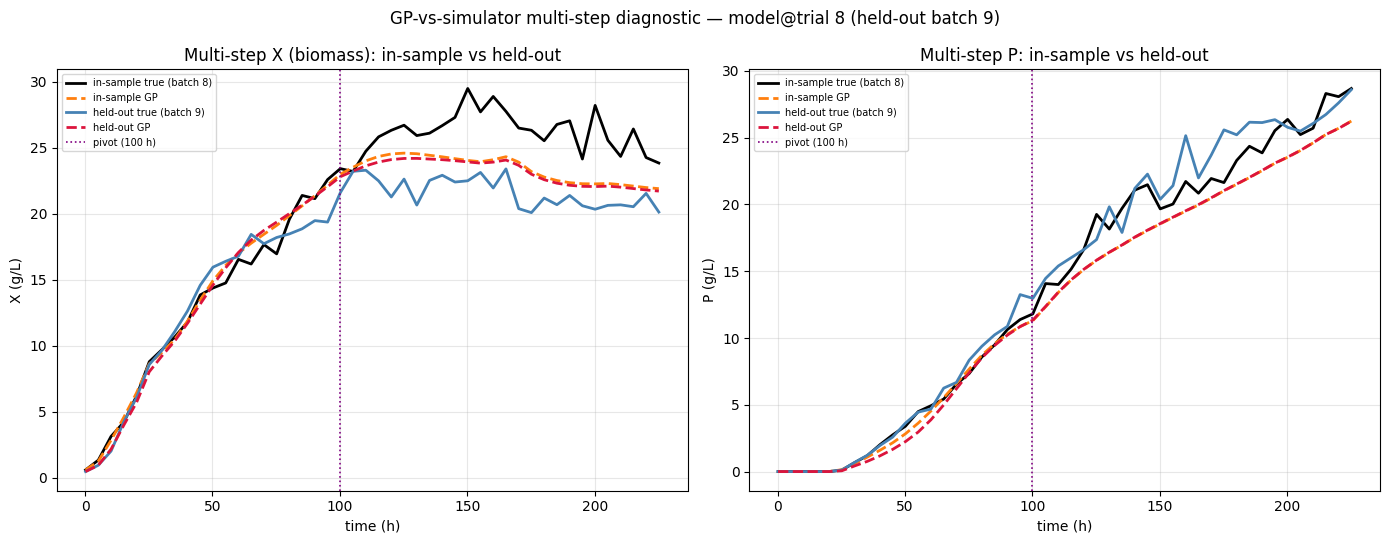

X rollout in-sample: final actual=23.86 g/L, GP=21.92 g/L
P rollout in-sample: final actual=28.67 g/L, GP=26.23 g/L


In [16]:
lib.plot_multistep_rollout(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, run.pivot_hours, show=True);


## C.2b GP multi-step uncertainty — all channels, with the model's own uncertainty

The GP's particle band (10-90%) and median vs its deterministic mean rollout (= C.2) and the
true simulator trajectory, for every channel, in-sample and held-out.

MSE Rollout dim0:  0.0007857023407383666
MSE Rollout dim1:  0.0009053505400486457
MSE Rollout dim2:  0.0008496513077479077
MSE Rollout dim3:  0.004075097229036933
MSE Rollout dim4:  4.5301221735369334e-31
MSE Rollout dim0:  0.0008146851925299269
MSE Rollout dim1:  0.0004945484472028713
MSE Rollout dim2:  0.0028627611307021693
MSE Rollout dim3:  0.007940548078249872
MSE Rollout dim4:  4.5301221735369334e-31


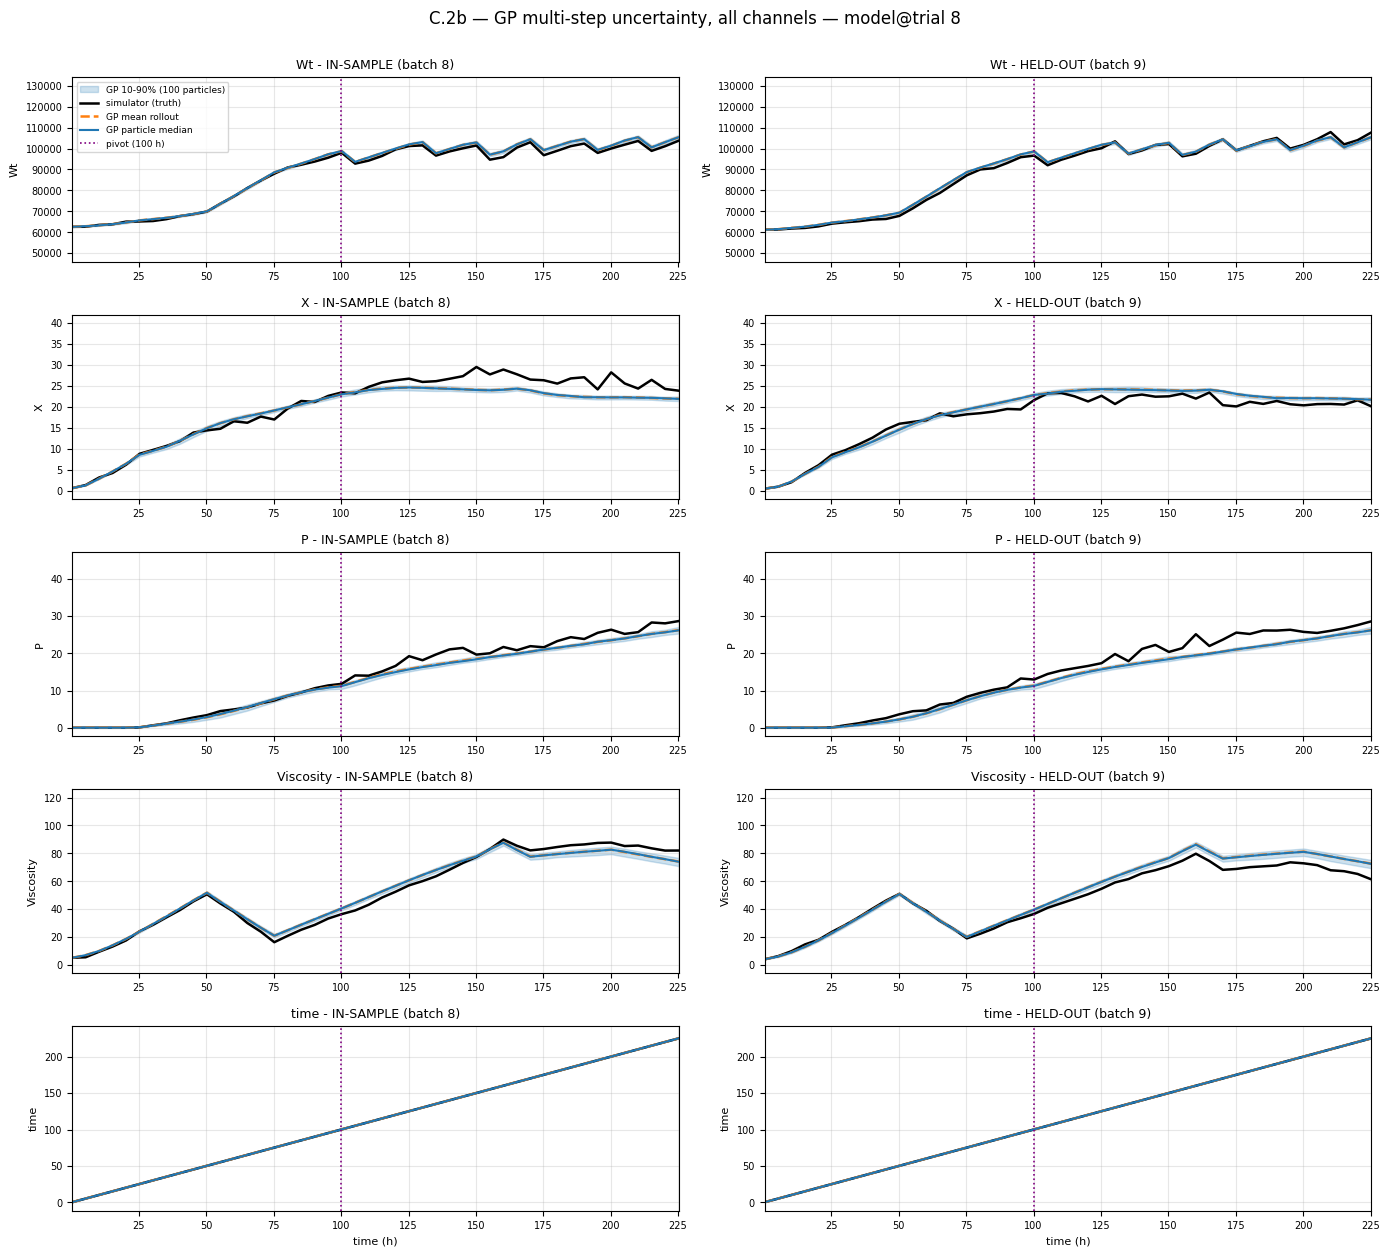

In [17]:
lib.plot_particle_bands(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, run.pivot_hours, show=True);


## C.4b One-step teacher-forced standardised residuals (GP calibration)

`z = (predicted - true) / pred_std`; a well-calibrated channel is ~N(0,1). `time` is
deterministic (variance pinned to a tiny jitter) -- ignore its panel.

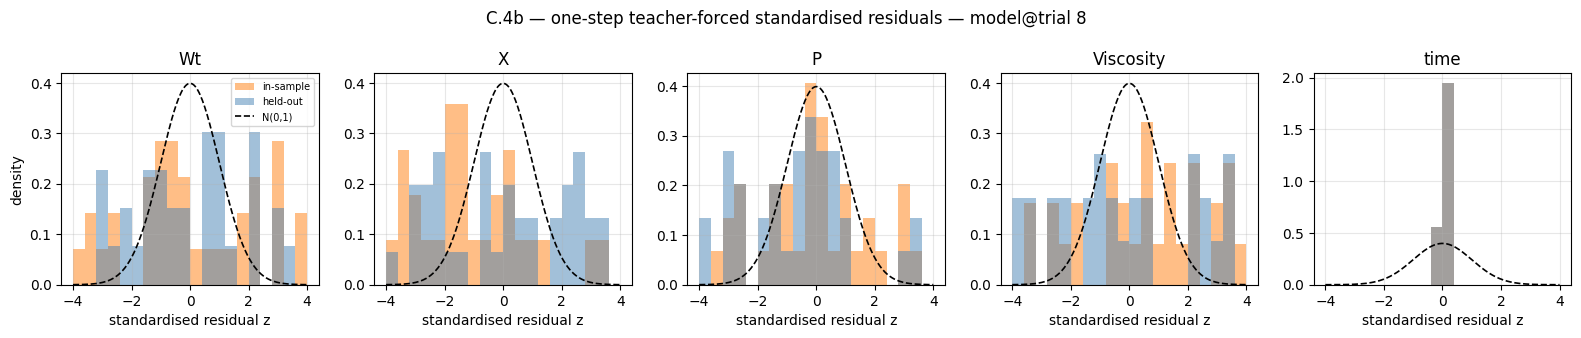

In [18]:
lib.plot_calibration(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, show=True);


## C.5 Local (one-step) error across the batch

Each estimate re-anchors on the truth, so there is no accumulation -- flat means late rollout
divergence is pure accumulation; growing late means a local model-quality problem.

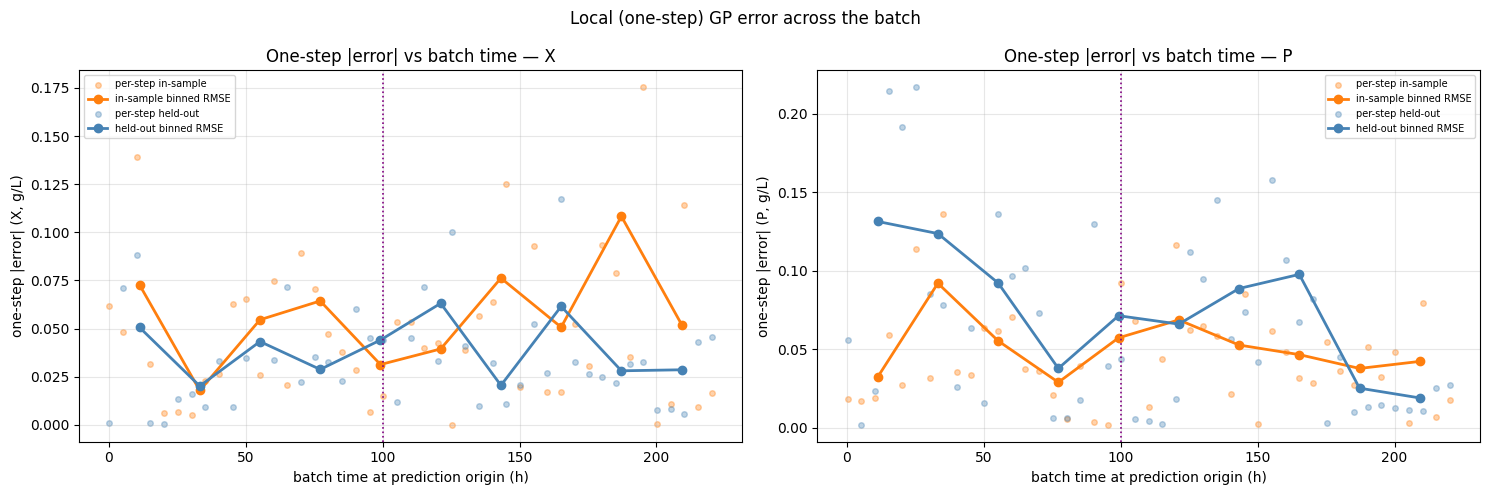

In [19]:
lib.plot_local_error(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, run.pivot_hours, show=True);


## C.6 k-step-ahead prediction error growth

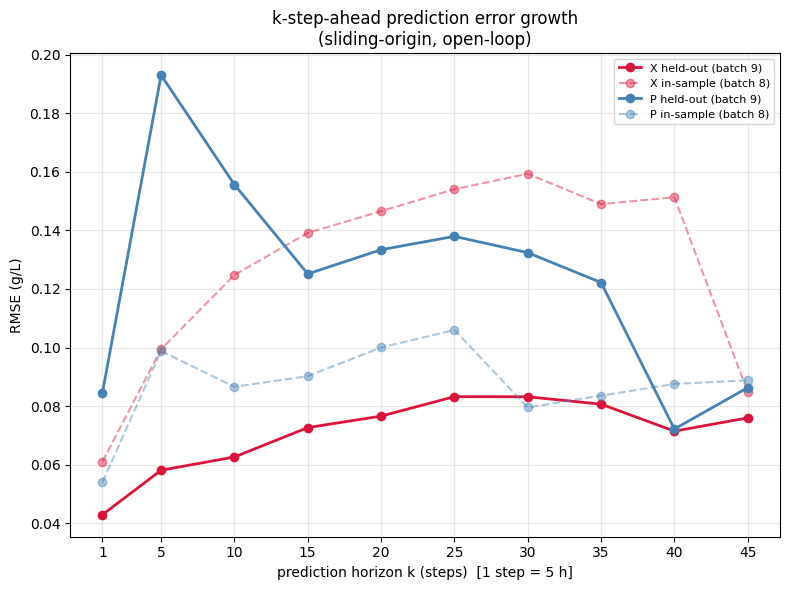

In [20]:
lib.plot_kstep_growth(gp_agent, GP_IDX, ho_idx, has_ho, OUT_DIR, show=True);


---
### Notes
- All comparisons use the discharge-aware `yield_kg` metric from `experiments/eval_utils`
  (identical to what the single-phase notebook and the recipe/BO baselines report).
- To evaluate a different run, change **RUN_ID** in the Config cell and re-run -- everything
  else is read back from that run's own files.
- Every plot/table above also wrote a PNG/CSV into `OUT_DIR` (the run's own folder); running
  `evaluations_multi_phase.py <run_id>` from the command line produces the identical files
  without opening a notebook.
